In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib import animation
import bottleneck as bn
import sunpy
import sunpy.map
from sunpy.coordinates import propagate_with_solar_surface
import h5py
from astropy.time import Time
from astropy.io import ascii, fits
from astropy.wcs import WCS
from astropy.visualization import (ImageNormalize, 
                    SqrtStretch, AsinhStretch)
import astropy.units as u
from astropy.coordinates import SkyCoord
from glob import glob 
from sunkit_image.enhance import wow
from map_coalign import MapSequenceCoalign

In [2]:
map_files = sorted(glob("../../data/20241015/hri_coalign/*.fits"))

In [4]:
hri_maps = MapSequenceCoalign(sunpy.map.Map(map_files))

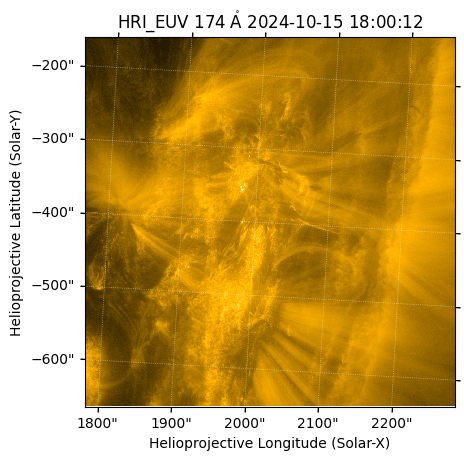

In [5]:
hri_maps[0].plot()

In [6]:
test_map = hri_maps[180]

In [7]:
test_map.data.shape

(1024, 1024)

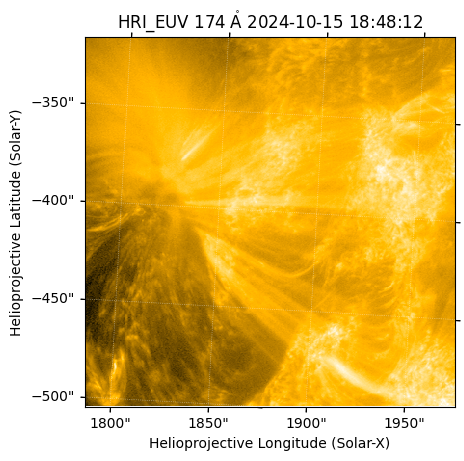

In [8]:
test_map = test_map.submap(bottom_left=(16,256+64)*u.pix,
                           top_right=(16+384-1, 256+64+384-1)*u.pix)
test_map.plot()

In [9]:
test_map_wow = wow(test_map,
                   bilateral=1, denoise_coefficients=[5,3,1], gamma=3.2, h=0.95)

In [10]:
hmi_map = sunpy.map.Map("../../data/hmi/20241015/hmi.ic_45s.20241015_200045_TAI.2.continuum.fits")
hmi_map_crop = hmi_map.submap(
    bottom_left=SkyCoord(340*u.arcsec, -250*u.arcsec, frame=hmi_map.coordinate_frame),
    top_right=SkyCoord(430*u.arcsec, -160*u.arcsec, frame=hmi_map.coordinate_frame)
)
hmi_map_crop.meta["rsun_ref"] = hri_maps[0].meta["rsun_ref"]

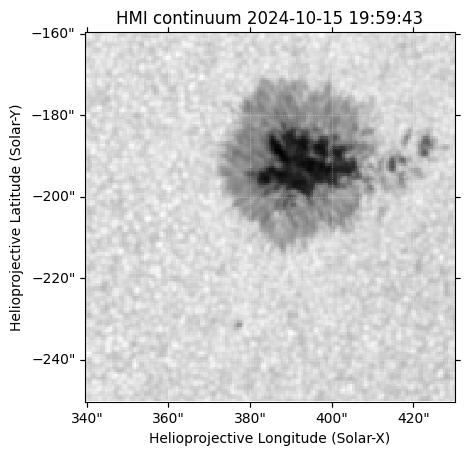

In [11]:
hmi_map_crop.plot()

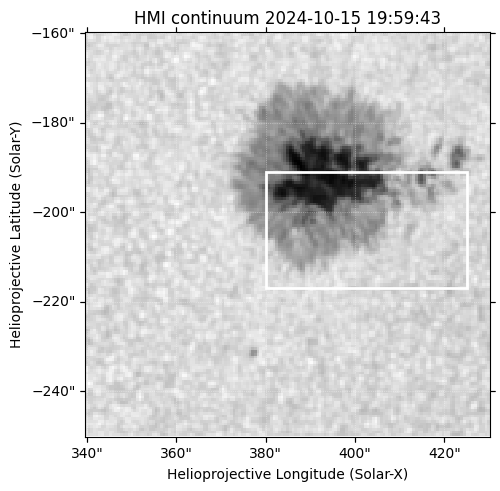

In [30]:
DL_bottom_left = SkyCoord(
    380*u.arcsec, -217*u.arcsec,
    frame=hmi_map_crop.coordinate_frame
)

DL_top_right = SkyCoord(
    (380+45)*u.arcsec,
    (-217+26)*u.arcsec,
    frame=hmi_map_crop.coordinate_frame
)


fig = plt.figure(layout="constrained")
ax = fig.add_subplot(projection=hmi_map_crop)
hmi_map_crop.plot(axes=ax)
hmi_map_crop.draw_quadrangle(
    bottom_left=DL_bottom_left,
    top_right=DL_top_right,
    edgecolor="white",
    linewidth=2
)

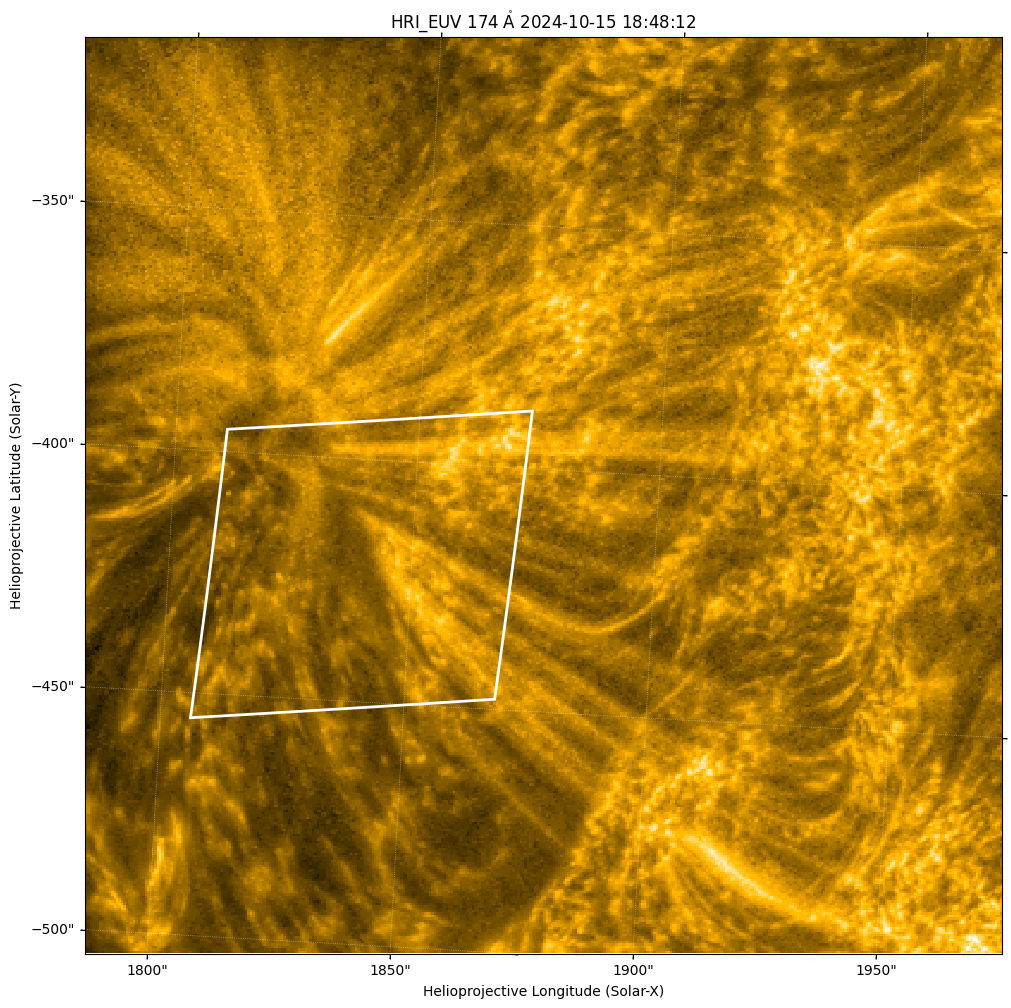

In [31]:
%matplotlib inline



with propagate_with_solar_surface():
    fig = plt.figure(figsize=(10,10), layout="constrained")
    ax = fig.add_subplot(projection=test_map_wow)
    test_map_wow.plot(norm=ImageNormalize(), axes=ax)

    hmi_map_crop.draw_quadrangle(
        bottom_left=DL_bottom_left,
        top_right=DL_top_right,
        edgecolor="white",
        linewidth=2
    )

In [13]:
hri_maps_crop = hri_maps.submap(
    bottom_left=(16,256+64)*u.pix,
    top_right=(16+384-1, 256+64+384-1)*u.pix
)

In [14]:
hri_maps_array = hri_maps_crop.data

In [15]:
hri_maps_array.shape

(384, 384, 1012)

In [16]:
hri_maps_array_mean_boxcar = bn.move_mean(hri_maps_array,window=3,axis=2,min_count=1)

In [17]:
test_map_boxcar = sunpy.map.Map(hri_maps_array_mean_boxcar[:,:,180], hri_maps_crop[180].meta)

In [19]:
test_map_boxcar_wow = wow(test_map_boxcar,
                   bilateral=1, denoise_coefficients=[5,3,1], gamma=3.2, h=0.95)

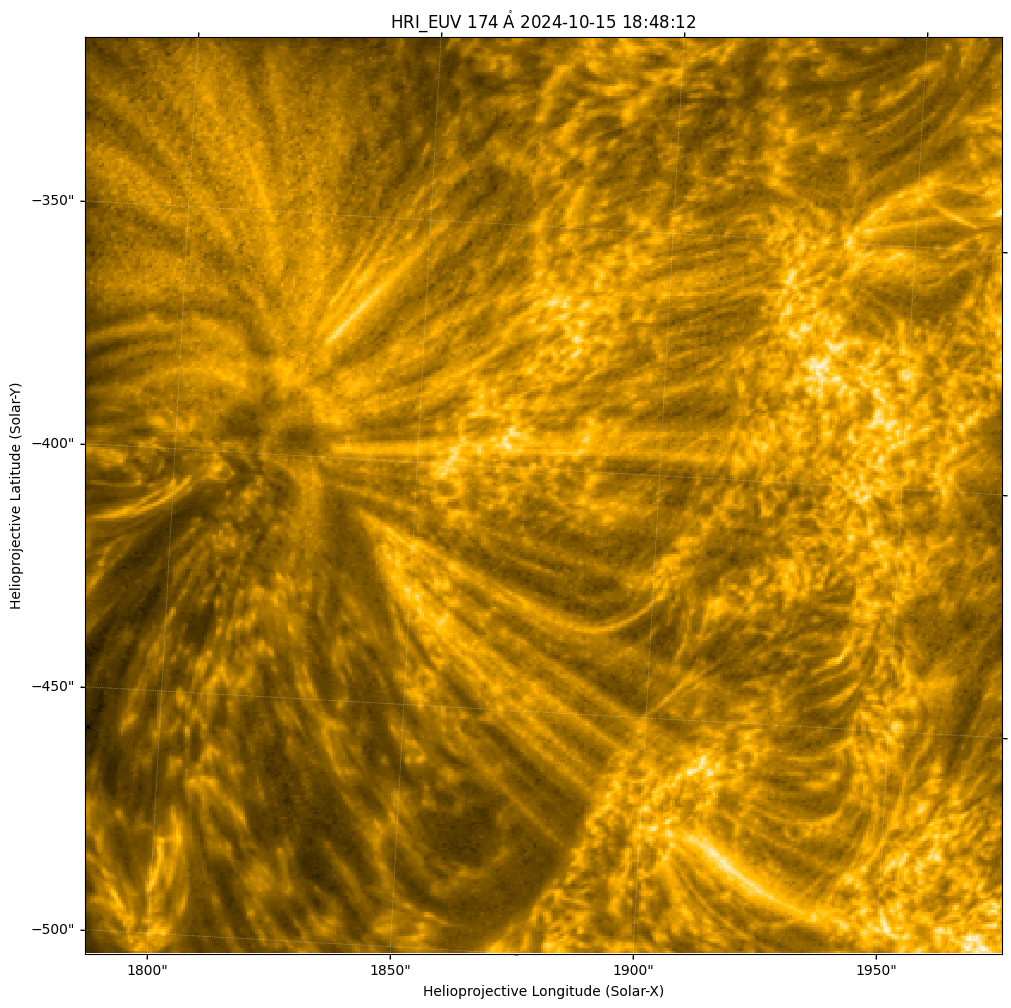

In [20]:
fig = plt.figure(figsize=(10,10), layout="constrained")
ax = fig.add_subplot(projection=test_map_boxcar_wow)
test_map_boxcar_wow.plot(norm=ImageNormalize(), axes=ax)

In [21]:
def make_movie(hri_maps_array_mean_boxcar, hri_maps, 
    DL_bottom_left, DL_top_right, hmi_map_crop, save_dir):
    map_0 = sunpy.map.Map(hri_maps_array_mean_boxcar[:,:,0], hri_maps[0].meta)
    map_0_wow = wow(map_0,
                   bilateral=1, denoise_coefficients=[5,3,1], gamma=3.2, h=0.95)    
    
    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(projection=map_0_wow)
    im = map_0_wow.plot(norm=ImageNormalize(), axes=ax, interpolation="none", title=None)
    title = ax.set_title("HRIEUV {}".format(hri_maps[0].date.strftime("%Y-%m-%dT%H:%M:%S")),
    fontdict={'fontsize': 12, 'family': 'monospace'})

    with propagate_with_solar_surface():
        hmi_map_crop.draw_quadrangle(
            bottom_left=DL_bottom_left,
            top_right=DL_top_right,
            edgecolor="white",
            linewidth=1.5,
            ls="--",
            alpha=0.65
        )

    plt.tight_layout()
    plt.show()
    
    def update_fig(ii, im, title):
        map_ = sunpy.map.Map(hri_maps_array_mean_boxcar[:,:,ii], hri_maps[ii].meta)
        map_wow = wow(map_,
                   bilateral=1, denoise_coefficients=[5,3,1], gamma=3.2, h=0.95)
        im.set_data(map_wow.data)
        title.set_text("HRIEUV {}".format(hri_maps[ii].date.strftime("%Y-%m-%dT%H:%M:%S")))
        return ax
    
    anim = animation.FuncAnimation(fig, update_fig, fargs=(im, title),
                                   frames=hri_maps_array_mean_boxcar.shape[2], #range(10), #
                                   blit=False)
    
    anim.save(save_dir, fps=30, dpi=150,writer='ffmpeg', 
          codec='libx264',
          # bitrate=6000,
          extra_args=['-pix_fmt', 'yuv420p'])
    
    return anim

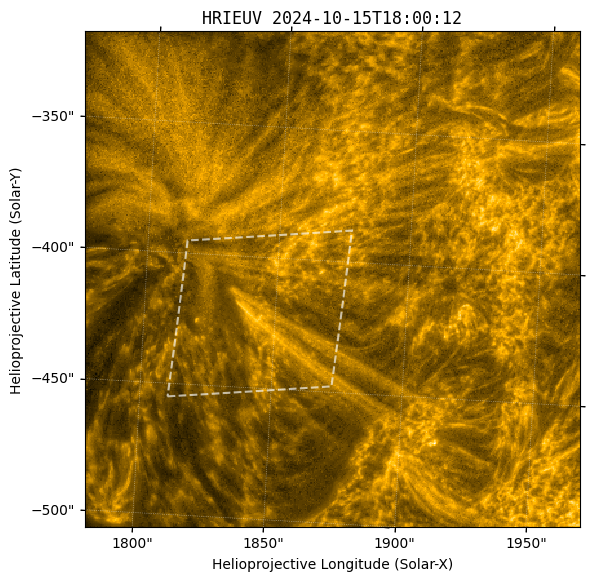

In [32]:
make_movie(hri_maps_array_mean_boxcar, hri_maps_crop,
           DL_bottom_left, DL_top_right, hmi_map_crop,
           "../../figs/test_movie/hrieuv_20241015_wow_DL_FOV.mp4")